# Face recognition with `sklearn` and eigenfaces

This example is adapted from the [`sklearn` tutorial](https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html) on face recognition using eigenfaces and SVMs.

They use a dataset containing images of 7 public figures, and try to produce a classifier that distinguishes between them. Instead of training the classifier directly on the high-dimensional input space, they first decompose the images into its principal components. This is a technique known as ['eigenfaces'](https://en.wikipedia.org/wiki/Eigenface).

They then tune the hyperparameters of an SVM and produce a reasonable classifier. Was this tuning necessary? We use `prob_conf_mat` to test this.

**Note**: the appearance of this notebook will depend on the environment and screen size you're using. If the tables are being clipped or the figures look off, consider trying Google Colab or Github via the buttons below. This notebook was created in VSCode, and will likely look best locally.

<a target="_blank" href="https://colab.research.google.com/github/ioverho/prob_conf_mat/blob/main/docs/getting_started/examples/eigenfaces.ipynb">
  <img alt="Static Badge" src="https://img.shields.io/badge/Run_in_Colab-_?style=for-the-badge&logo=googlecolab&labelColor=gray&color=1082c3&link=https%3A%2F%2Fgithub.com%2Fioverho%2Fprob_conf_mat%2Fblob%2Fmain%2Fdocs%2Fgetting_started%2Fexamples/eigenfaces.ipynb">
</a>
<a target="_blank" href="https://github.com/ioverho/prob_conf_mat/blob/main/docs/getting_started/examples/eigenfaces.ipynb">
  <img alt="Static Badge" src="https://img.shields.io/badge/View_in_Github-_?style=for-the-badge&logo=github&labelColor=gray&color=1082c3&link=https%3A%2F%2Fgithub.com%2Fioverho%2Fprob_conf_mat%2Fblob%2Fmain%2Fdocs%2Fgetting_started%2Fexamples/eigenfaces.ipynb">
</a>

In [1]:
import subprocess

# Installation on Google Colab
try:
    import google.colab

    subprocess.run(
        [
            "python",
            "-m",
            "pip",
            "install",
            "prob_conf_mat"
        ]
    )
except ImportError:
    pass

In [2]:
from time import time

import numpy as np
import scipy
import scipy.stats
import sklearn
import matplotlib.pyplot as plt

import prob_conf_mat as pcm

## Pre-Processing

First load the dataset.

**Note**: this downloads the data to disk.

In [20]:
lfw_people = sklearn.datasets.fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the 2 data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("Total dataset size:")
print(f"n_samples: {n_samples}")
print(f"n_features: {n_features}")
print(f"n_classes: {n_classes}")
print(f"features: {h * w}")

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7
features: 1850


Split into a training set and a test and keep 25% of the data for testing.

In [4]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

Compute a PCA (eigenfaces) on the face dataset (treated as unlabeled dataset): unsupervised feature extraction / dimensionality reduction

In [5]:
n_components = 150

print(
    f"Extracting the top {n_components} eigenfaces from {X_train.shape[0]} faces"
)

preprocessing_pipeline = sklearn.pipeline.make_pipeline(
    sklearn.preprocessing.StandardScaler(),
    sklearn.decomposition.PCA(n_components=n_components, svd_solver="randomized", whiten=True),
)

t0 = time()
preprocessing_pipeline.fit(X_train)
print("done in %0.3fs" % (time() - t0))

Extracting the top 150 eigenfaces from 966 faces
done in 0.516s


In [6]:
print("Projecting the input data on the eigenfaces orthonormal basis")
t0 = time()
X_train_pca = preprocessing_pipeline.transform(X_train)
X_test_pca = preprocessing_pipeline.transform(X_test)
print("done in %0.3fs" % (time() - t0))

Projecting the input data on the eigenfaces orthonormal basis
done in 0.050s


### Intermezzo: What are eigenfaces?

**Warning**: nightmare fuel ahead.

We used PCA to decompose the dataset into its principal components (directions of maximal variation), and kept the first 150. This discards nearly 90% of our input dimensions. Interestingly enough, the eigenface components somewhat resemble facial features.

In [21]:
eigenfaces = preprocessing_pipeline["pca"].components_.reshape((n_components, h, w))

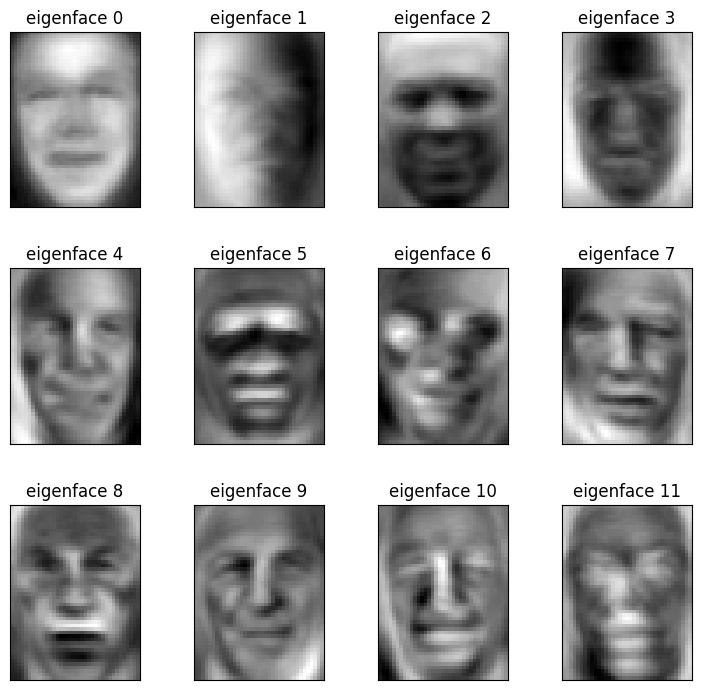

In [22]:
n_col = 4
n_row = 3

eigenface_titles = [f"eigenface {i}" for i in range(eigenfaces.shape[0])]

plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
for i in range(n_row * n_col):
    plt.subplot(n_row, n_col, i + 1)
    plt.imshow(eigenfaces[i].reshape((h, w)), cmap=plt.cm.gray)
    plt.title(eigenface_titles[i], size=12)
    plt.xticks(())
    plt.yticks(())

We can now use these eigenfaces to reconstruct an image.

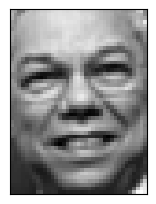

In [26]:
plt.figure(figsize=(1.8, 2.4))

plt.imshow(X_train[128].reshape((h, w)), cmap=plt.cm.gray)
plt.xticks(())
plt.yticks(())

plt.show()

We simply take the image, transform it using the learned PCA model to gives us the weights assigned to each PCA dimension, and reconstruct the image using a weighted sum of the 150 PCA dimensions.

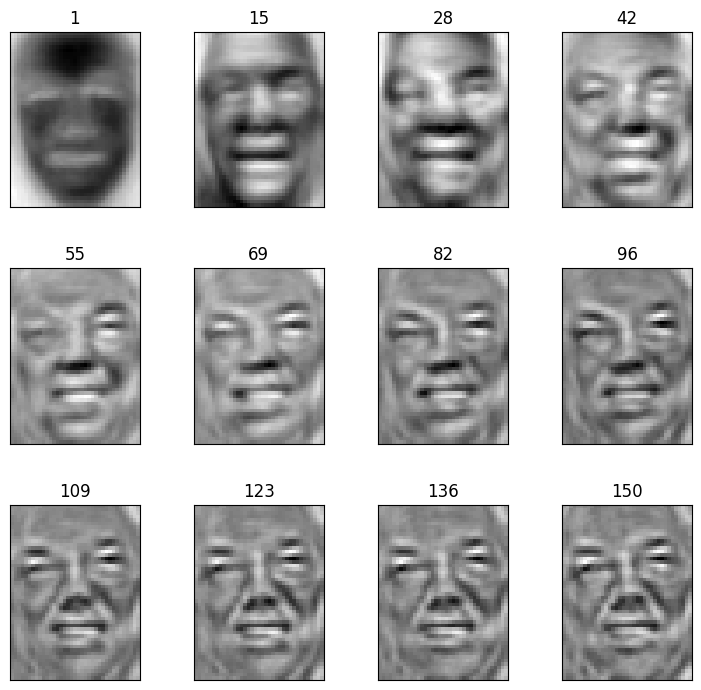

In [27]:
n_col = 4
n_row = 3

reconstructed_eigenface = np.cumsum(
    preprocessing_pipeline.transform(X_train[128][np.newaxis, :]).reshape(-1, 1, 1)
    * eigenfaces,
    axis=0,
)

steps = np.round(np.linspace(0, 150-1, n_col * n_row)).astype(int)

plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
for i in range(n_row * n_col):
    plt.subplot(n_row, n_col, i + 1)
    plt.imshow(reconstructed_eigenface[steps[i]].reshape((h, w)), cmap=plt.cm.gray)
    plt.title(f"{steps[i]+1}", size=12)
    plt.xticks(())
    plt.yticks(())

The first dimensions correspond to coarse grained features (location of mouth, eyes and nose), while the succeeding PCA dimensions add increasingly finer details to the image. Using all 150 dimensions yields an imperfect, but recognizable face. A classifier should, in theory, be able to distinguish between the different identities using these features.

## Classification

First we train an SVM classification model with default parameters.

In [11]:
print("Fitting SVM with default parameters")

t0 = time()

clf = sklearn.svm.SVC(kernel="rbf", class_weight="balanced")

clf = clf.fit(X_train_pca, y_train)

print("done in %0.3fs" % (time() - t0))

Fitting SVM with default parameters
done in 0.062s


Then we perform an expensive hyperparameter search to find the optimal parameters.

In [12]:
print("Performing hyperparameter search with classifier")

t0 = time()

param_grid = {
    "C": scipy.stats.loguniform(1.0e+3, 1.0e+5),
    "gamma": scipy.stats.loguniform(1.0e-4, 1.0e-1),
}

clf_opt = sklearn.model_selection.RandomizedSearchCV(
    sklearn.svm.SVC(kernel="rbf", class_weight="balanced"), param_grid, n_iter=100
)

clf_opt = clf_opt.fit(X_train_pca, y_train)

print("done in %0.3fs" % (time() - t0))
print("Best estimator found by grid search:")
clf_opt.best_estimator_

Performing hyperparameter search with classifier
done in 22.405s
Best estimator found by grid search:


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(44681.157461518844)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",np.float64(0....3794159490331)
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Analysis

### Configuration

First we define a study. We can use the `prob_conf_mat.io.compute_confusion_matrix` utility function to convert the `sklearn` predictions to the needed confusion matrix format. The dataset is imbalanced, so we'll use the MCC score isntead of accuracy.

In [30]:
study = pcm.Study(
    seed=0,
    num_samples=10000,
    ci_probability=0.95,
)

study.add_metric("mcc")

In [31]:
study.add_experiment(
    experiment_name="default",
    confusion_matrix=pcm.io.compute_confusion_matrix(
        y_true=y_test,
        y_pred=clf.predict(X_test_pca),
    ),
    prevalence_prior=0,
    confusion_prior=0,
)

study.add_experiment(
    experiment_name="optimal",
    confusion_matrix=pcm.io.compute_confusion_matrix(
        y_true=y_test,
        y_pred=clf_opt.predict(X_test_pca),
    ),
    prevalence_prior=0,
    confusion_prior=0,
)


### Reports

Overall, the models perform well, achieving a $0.8$ MCC score, which is well above random performance.

In [15]:
study.report_metric_summaries(metric="mcc")

Group,Experiment,Observed,Median,Mode,95.0% HDI,MU,Skew,Kurt
default,default,0.7742,0.7746,0.7804,"[0.7224, 0.8265]",0.1041,-0.1668,0.0484
optimal,optimal,0.8019,0.8028,0.8079,"[0.7523, 0.8534]",0.1011,-0.2133,0.0286


### Comparison

Was the hyperparameter search worth it? It yield a $0.03$ bump in MCC points, but there is not enough testing data available to conclude that the optimized model is actually better. We'll need to repeat this experiment more often (e.g., cross-validation), or collect a larger test set.

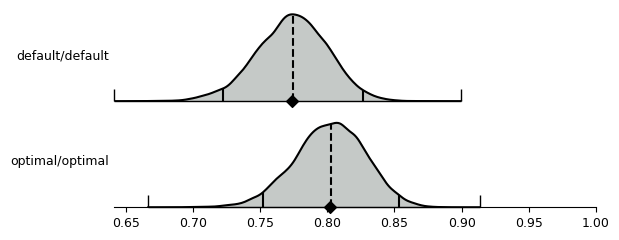

In [32]:
study.plot_metric_summaries(metric="mcc");

In [33]:
print(
    study.report_pairwise_comparison(
        metric="mcc",
        experiment_a="optimal",
        experiment_b="default",
        min_sig_diff=0.005,
    )
)

Experiment optimal's mcc being greater than default could be considered 'dubious'* (Median Δ=0.0283, 95.00% HDI=[-0.0456, 0.0969], p_direction=77.75%).

There is a 92.04% probability that this difference is bidirectionally significant (ROPE=[-0.0050, 0.0050], p_ROPE=7.96%).

Bidirectional significance could be considered 'undecided'*.

There is a 73.52% probability that this difference is significantly positive (p_pos=73.52%, p_neg=18.52%).

Relative to two random models (p_ROPE,random=12.11%) significance is 1.5932 times more likely.

* These interpretations are based off of loose guidelines, and should change according to the application.


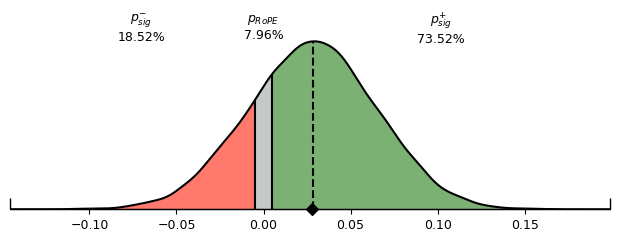

In [34]:
study.plot_pairwise_comparison(
    metric="mcc",
    experiment_a="optimal",
    experiment_b="default",
    min_sig_diff=0.005,
);